# VIP-SLAP2 all-modality data crunching notebook

This notebook is a deployment notebook for session-level preprocessing, QC, and event extraction across the VIP synaptic dynamics dataset.

It is intended to replace the scratch-style workflow in `VIP_SD_SessionAssetModel_DataProcessing.ipynb` with one consistent processing entry point for:

- behavior / HARP / photodiode QC
- glutamate SLAP2 QC and image/change/omission extraction
- calcium QC and extraction for paired red calcium channels
- voltage QC and event extraction using the new voltage asset model

The voltage pathway assumes the repo has been updated with:

- `vip_slap2_analysis.common.alignment`
- generic `SessionAssets.modality_assets`
- `vip_slap2_analysis.voltage.qc.run_voltage_qc`
- `vip_slap2_analysis.voltage.extraction.process_voltage_extraction`


In [1]:
# Notebook display + autoreload
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import json
import traceback
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [11]:
%matplotlib notebook

## 1. Configure paths and processing switches

Adjust the path variables and `target_mice` list before running. The `RUN_*` switches let you rerun individual stages without editing the main loop.


In [2]:
# ---------------------------------------------------------------------
# Local repository / data paths
# ---------------------------------------------------------------------
# If running from inside the repo, this can usually stay as None.
# If imports fail, set REPO_ROOT to your local clone, e.g.
# REPO_ROOT = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis")
REPO_ROOT = None

if REPO_ROOT is not None:
    src_path = Path(REPO_ROOT) / "src"
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

# Optional local copy of the summary table. The registry discovers sessions from BASE_PATH;
# this file is only useful for ad hoc inspection or manual cross-checks.
SUMMARY_XLSX = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\VIP_SD_summary.xlsx")

# ---------------------------------------------------------------------
# Session selection
# ---------------------------------------------------------------------
target_mice = [
    826031,
    826032,
]

EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
PARADIGMS = ["change_detection_passive"]

# ---------------------------------------------------------------------
# Execution controls
# ---------------------------------------------------------------------
RUN_BEHAVIOR = True
RUN_GLUTAMATE_QC = True
RUN_GLUTAMATE_EXTRACTION = True
RUN_CALCIUM_QC = True
RUN_CALCIUM_EXTRACTION = True
RUN_VOLTAGE_QC = True
RUN_VOLTAGE_EXTRACTION = True

# Recompute outputs even if they already exist.
OVERWRITE_BEHAVIOR = False
OVERWRITE_QC = False
OVERWRITE_EXTRACTION = False

# Development controls for expensive steps.
MAKE_PLOTS = True
MAX_SESSION_MINUTES_CALCIUM = None       # e.g. 15 for development; None for full session
MAX_TRIALS_FOR_VOLTAGE_QC = None        # e.g. 10 for development; None for full QC

# If True, behavior failures prevent physiology extraction.
REQUIRE_BEHAVIOR_READY = True

# If True, do not execute processing calls; only build assets/status table.
DRY_RUN = False

## 2. Import pipeline entry points

These imports define the expected public API for the processing pipeline.


In [3]:
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.behavior.preprocess import process_behavior_session

from vip_slap2_analysis.common.qc import run_session_synapse_qc
from vip_slap2_analysis.glutamate.extraction import process_glutamate_extraction

from vip_slap2_analysis.calcium.qc import run_calcium_qc
from vip_slap2_analysis.calcium.extraction import process_calcium_extraction

from vip_slap2_analysis.voltage.qc import run_voltage_qc
from vip_slap2_analysis.voltage.extraction import (
    process_voltage_extraction,
    compute_voltage_roi_transform_from_asset,
    load_voltage_roi_transform_h5,
)

## 3. Define modality-specific metadata and extraction settings

The event windows are kept explicit so behavior, glutamate, calcium, and voltage use the same conceptual event definitions.


In [4]:
# Behavior alignment / epoch metadata
BEHAVIOR_METADATA = {
    "epochs_mode": "continuous",
    "prepost_sec": {
        "image_identity": (0.25, 0.750),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}

# Glutamate and calcium are currently treated as frame-rate data.
FRAME_RATE_HZ = 200.0

GLUTAMATE_METADATA = {
    "im_rate_hz": FRAME_RATE_HZ,
    "prepost_sec": {
        "image": (0.25, 0.50),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}

CALCIUM_METADATA = {
    "im_rate_hz": FRAME_RATE_HZ,
    "prepost_sec": {
        "image": (0.25, 0.750),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}

# Voltage: SLAP2 integration-mode line/sample rate.
VOLTAGE_SAMPLE_RATE_HZ = 10_800.0

# Recommended first-pass voltage extraction signals:
# - dff_static_f0: most conservative for long slow oscillations/state dynamics
# - dff_robust_f0: useful default for event-aligned response/sequence analyses
VOLTAGE_TRACE_SIGNALS = [
    "dff_static_f0",
    "dff_robust_f0",
]

VOLTAGE_EXTRACTION_KWARGS = {
    "sample_rate_hz": VOLTAGE_SAMPLE_RATE_HZ,
    "trace_mode": "trial",
    "use_roi_qc": True,
    "write_session_traces": True,
    "f0_percentile": 50.0,
    "robust_f0_bin_sec": 5.0,
    "robust_f0_smooth_sec": 180.0,
}

VOLTAGE_QC_KWARGS = {
    "sample_rate_hz": VOLTAGE_SAMPLE_RATE_HZ,
    "trace_mode": "trial",
    "drop_discarded": True,
    "make_plots": MAKE_PLOTS,
    "max_trials_for_metrics": MAX_TRIALS_FOR_VOLTAGE_QC,
}

## 4. Resolve sessions and inspect discovered assets

The registry should now discover both conventional `SummaryLoCo*.mat` assets and voltage `dendriticVoltageSummary*.mat` / `dendriticVoltageTraces*.h5` assets via `SessionAssets.modality_assets`.


In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions for target mice: {target_mice}")
display(process_df.head())

Found 19 candidate sessions for target mice: [826031, 826032]


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [6]:
def get_modality_asset(asset, modality, key):
    """Safely retrieve a modality asset from the generic asset model."""
    if hasattr(asset, "get_asset"):
        return asset.get_asset(modality, key)
    return None


def has_modality_asset(asset, modality, required_keys=("summary_mat",)):
    """Return True if required modality asset keys are present."""
    if hasattr(asset, "has_modality"):
        try:
            return bool(asset.has_modality(modality, {k: None for k in required_keys}))
        except TypeError:
            # In case the local helper signature differs from the generated draft.
            return all(get_modality_asset(asset, modality, k) is not None for k in required_keys)
    return all(get_modality_asset(asset, modality, k) is not None for k in required_keys)


def metadata_text(asset):
    """Concatenate metadata values into one lowercase string for lightweight modality heuristics."""
    meta = getattr(asset, "metadata", None) or {}
    parts = []
    for value in meta.values():
        if isinstance(value, (str, int, float)):
            parts.append(str(value))
    return " ".join(parts).lower()


def infer_modalities(asset):
    """Infer which processing branches should run for an asset.

    The asset model is the source of truth for voltage because voltage has distinct
    dendriticVoltageSummary/dendriticVoltageTraces files. Glutamate/calcium currently
    share the SummaryLoCo-style asset family, so metadata indicators are used as a
    lightweight heuristic.
    """
    meta = metadata_text(asset)

    has_voltage_files = has_modality_asset(asset, "voltage", ("summary_mat", "trace_h5"))
    voltage_by_indicator = any(tok in meta for tok in ["asap", "voltron", "voltage"])

    has_summary = getattr(asset, "summary_mat", None) is not None
    glutamate_by_indicator = any(tok in meta for tok in ["iglusnfr", "glutamate", "glusnfr"])
    calcium_by_indicator = any(tok in meta for tok in ["rcamp", "jrgeco", "gcamp", "camp", "calcium"])

    # Conservative defaults:
    # - run voltage only when voltage files are present
    # - run glutamate whenever a SummaryLoCo-style summary exists and the session is not voltage-only
    # - run calcium only when metadata indicates a calcium channel
    return {
        "behavior": True,
        "voltage": bool(has_voltage_files),
        "glutamate": bool(has_summary and (glutamate_by_indicator or not has_voltage_files)),
        "calcium": bool(has_summary and calcium_by_indicator),
        "voltage_by_indicator_without_files": bool(voltage_by_indicator and not has_voltage_files),
    }


def asset_summary_row(asset):
    mods = infer_modalities(asset)
    return {
        "subject_id": getattr(asset, "subject_id", None),
        "session_id": getattr(asset, "session_id", None),
        "summary_mat": getattr(asset, "summary_mat", None),
        "voltage_summary_mat": get_modality_asset(asset, "voltage", "summary_mat"),
        "voltage_trace_h5": get_modality_asset(asset, "voltage", "trace_h5"),
        "bonsai_event_log_csv": getattr(asset, "bonsai_event_log_csv", None),
        "harp_dir": getattr(asset, "harp_dir", None),
        "photodiode_pkl": getattr(asset, "photodiode_pkl", None),
        **{f"run_{k}": v for k, v in mods.items()},
    }

asset_df = pd.DataFrame([asset_summary_row(a) for a in assets])
display(asset_df)

,subject_id,session_id,summary_mat,voltage_summary_mat,voltage_trace_h5,bonsai_event_log_csv,harp_dir,photodiode_pkl,run_behavior,run_voltage,run_glutamate,run_calcium,run_voltage_by_indicator_without_files
0,826031,826031_2026-01-30_15-04-02,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
1,826031,826031_2026-02-01_11-01-50,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
2,826031,826031_2026-02-02_10-23-53,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
3,826031,826031_2026-02-03_14-21-45,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
4,826031,826031_2026-02-04_12-15-34,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
5,826031,826031_2026-02-05_09-28-56,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
6,826031,826031_2026-02-06_10-21-20,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
7,826031,826031_2026-02-10_10-48-51,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
8,826031,826031_2026-02-11_12-42-21,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
9,826031,826031_2026-02-12_07-43-37,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False


## 5. Processing helpers

The main loop below records status for every stage. A failure in one stage is captured in the status table rather than stopping the entire batch.


In [7]:
def run_stage(stage_name, fn, *args, **kwargs):
    """Run one processing stage and capture status without killing the batch."""
    if DRY_RUN:
        return {"stage": stage_name, "status": "dry_run", "result": None, "error": None}

    try:
        result = fn(*args, **kwargs)
        status = getattr(result, "status", "ok")
        return {"stage": stage_name, "status": status, "result": result, "error": None}
    except Exception as exc:
        return {
            "stage": stage_name,
            "status": "error",
            "result": None,
            "error": "".join(traceback.format_exception_only(type(exc), exc)).strip(),
            "traceback": traceback.format_exc(),
        }


def append_record(records, asset, stage_result, extra=None):
    rec = {
        "subject_id": getattr(asset, "subject_id", None),
        "session_id": getattr(asset, "session_id", None),
        "stage": stage_result.get("stage"),
        "status": stage_result.get("status"),
        "error": stage_result.get("error"),
    }
    if extra:
        rec.update(extra)
    records.append(rec)


def print_asset_header(asset):
    print("\n" + "=" * 100)
    print(f"SUBJECT: {asset.subject_id} | SESSION: {asset.session_id}")
    print("-" * 100)
    print("summary_mat:        ", getattr(asset, "summary_mat", None))
    print("voltage_summary:    ", get_modality_asset(asset, "voltage", "summary_mat"))
    print("voltage_trace_h5:   ", get_modality_asset(asset, "voltage", "trace_h5"))
    print("bonsai_event_log:   ", getattr(asset, "bonsai_event_log_csv", None))
    print("harp_dir:           ", getattr(asset, "harp_dir", None))
    print("photodiode_pkl:     ", getattr(asset, "photodiode_pkl", None))
    print("modalities:         ", infer_modalities(asset))
    print("=" * 100)


def behavior_ready_from_result(result):
    if result is None:
        return False
    return bool(getattr(result, "ready_for_physiology_extraction", False))

## 6. Main batch-processing loop

Run this cell to process all selected sessions. For voltage sessions, this runs voltage QC first, then extracts each signal listed in `VOLTAGE_TRACE_SIGNALS`.


In [8]:
status_records = []
results_by_session = {}

for asset in assets:
    print_asset_header(asset)
    asset.ensure_dirs()
    modalities = infer_modalities(asset)
    session_key = f"{asset.subject_id}_{asset.session_id}"
    results_by_session[session_key] = {}

    # ---------------------------------------------------------------
    # Behavior / HARP / photodiode QC and time alignment
    # ---------------------------------------------------------------
    behavior_result = None
    if RUN_BEHAVIOR:
        print("Processing behavior/HARP/photodiode alignment...")
        stage = run_stage(
            "behavior",
            process_behavior_session,
            asset,
            metadata=BEHAVIOR_METADATA,
            overwrite_harp_extract=OVERWRITE_BEHAVIOR,
            overwrite_alignment=OVERWRITE_BEHAVIOR,
            save_corrected_in_place=True,
            min_epoch_duration=6.0,
            trial_gap_start=0.02,
            expected_trial_epoch_min=None,
            use_piecewise_warp=True,
        )
        behavior_result = stage["result"]
        results_by_session[session_key]["behavior"] = behavior_result
        append_record(status_records, asset, stage, extra={
            "ready_for_physiology_extraction": behavior_ready_from_result(behavior_result),
            "failure_stage": getattr(behavior_result, "failure_stage", None) if behavior_result else None,
            "failure_reasons": getattr(behavior_result, "failure_reasons", None) if behavior_result else None,
        })
        print(f"Behavior status: {stage['status']}")
        if stage.get("error"):
            print(stage["error"])

    if REQUIRE_BEHAVIOR_READY and RUN_BEHAVIOR and not behavior_ready_from_result(behavior_result):
        print("Skipping physiology extraction because behavior is not ready.")
        continue

    # ---------------------------------------------------------------
    # Glutamate QC + extraction
    # ---------------------------------------------------------------
    if modalities["glutamate"]:
        if RUN_GLUTAMATE_QC:
            print("Running SLAP2/glutamate synapse QC...")
            stage = run_stage(
                "glutamate_qc",
                run_session_synapse_qc,
                summary_mat_path=asset.summary_mat,
                output_dir=asset.qc_dir / "slap2",
                session_id=asset.session_id,
                subject_id=asset.subject_id,
                trace_signal="dF",
                trace_mode="ls",
                save=True,
                make_plots=MAKE_PLOTS,
            )
            results_by_session[session_key]["glutamate_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Glutamate QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_GLUTAMATE_EXTRACTION:
            print("Extracting glutamate image/change/omission responses...")
            stage = run_stage(
                "glutamate_extraction",
                process_glutamate_extraction,
                asset,
                metadata=GLUTAMATE_METADATA,
                use_synapse_qc=True,
                overwrite=OVERWRITE_EXTRACTION,
                trace_signal="dFF",
                trace_mode="ls",
            )
            results_by_session[session_key]["glutamate_extraction"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Glutamate extraction status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])
    else:
        print("Skipping glutamate branch: no compatible SummaryLoCo/glutamate assets detected.")

    # ---------------------------------------------------------------
    # Calcium QC + extraction
    # ---------------------------------------------------------------
    if modalities["calcium"]:
        if RUN_CALCIUM_QC:
            print("Running calcium QC...")
            stage = run_stage(
                "calcium_qc",
                run_calcium_qc,
                asset,
                metadata={"im_rate_hz": FRAME_RATE_HZ},
                overwrite=OVERWRITE_QC,
                motion_correct=True,
                max_session_minutes=MAX_SESSION_MINUTES_CALCIUM,
            )
            results_by_session[session_key]["calcium_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Calcium QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_CALCIUM_EXTRACTION:
            print("Extracting calcium image/change/omission responses...")
            stage = run_stage(
                "calcium_extraction",
                process_calcium_extraction,
                asset,
                metadata=CALCIUM_METADATA,
                use_soma_qc=True,
                motion_correct=True,
                max_session_minutes=MAX_SESSION_MINUTES_CALCIUM,
                overwrite=OVERWRITE_EXTRACTION,
            )
            results_by_session[session_key]["calcium_extraction"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Calcium extraction status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])
    else:
        print("Skipping calcium branch: no calcium indicator detected in metadata.")

    # ---------------------------------------------------------------
    # Voltage QC + extraction
    # ---------------------------------------------------------------
    if modalities["voltage"]:
        if RUN_VOLTAGE_QC:
            print("Running voltage QC...")
            stage = run_stage(
                "voltage_qc",
                run_voltage_qc,
                asset,
                overwrite=OVERWRITE_QC,
                **VOLTAGE_QC_KWARGS,
            )
            results_by_session[session_key]["voltage_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Voltage QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_VOLTAGE_EXTRACTION:
            for trace_signal in VOLTAGE_TRACE_SIGNALS:
                print(f"Extracting voltage responses: {trace_signal}...")
                stage = run_stage(
                    f"voltage_extraction_{trace_signal}",
                    process_voltage_extraction,
                    asset,
                    trace_signal=trace_signal,
                    overwrite=OVERWRITE_EXTRACTION,
                    **VOLTAGE_EXTRACTION_KWARGS,
                )
                results_by_session[session_key][f"voltage_extraction_{trace_signal}"] = stage["result"]
                append_record(status_records, asset, stage, extra={"trace_signal": trace_signal})
                print(f"Voltage extraction {trace_signal} status: {stage['status']}")
                if stage.get("error"):
                    print(stage["error"])
    else:
        if modalities["voltage_by_indicator_without_files"]:
            print("Metadata suggests voltage indicator, but voltage summary/H5 files were not detected.")
        else:
            print("Skipping voltage branch: no voltage extraction assets detected.")

status_df = pd.DataFrame(status_records)
display(status_df)


SUBJECT: 826031 | SESSION: 826031_2026-01-30_15-04-02
----------------------------------------------------------------------------------------------------
summary_mat:         None
voltage_summary:     \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\826031_2026-01-30_15-04-02_slap2_2026-01-30_15-04-02\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260603-140324.mat
voltage_trace_h5:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\826031_2026-01-30_15-04-02_slap2_2026-01-30_15-04-02\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260603-140324.h5
bonsai_event_log:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\826031_2026-01-30_15-04-02\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
harp_dir:            \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04

C:\Users\andrew.shelton\Anaconda3\lib\site-packages\fontTools\misc\py23.py:11: DeprecationWarning: The py23 module has been deprecated and will be removed in a future release. Please update your code.
  warnings.warn(


Voltage QC status: ok
Extracting voltage responses: dff_static_f0...
Voltage extraction dff_static_f0 status: ok
Extracting voltage responses: dff_robust_f0...
Voltage extraction dff_robust_f0 status: ok

SUBJECT: 826031 | SESSION: 826031_2026-02-01_11-01-50
----------------------------------------------------------------------------------------------------
summary_mat:         None
voltage_summary:     \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\826031_2026-02-01_11-01-50_slap2_2026-02-01_11-01-50\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260504-150214.mat
voltage_trace_h5:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\826031_2026-02-01_11-01-50_slap2_2026-02-01_11-01-50\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260504-150214.h5
bonsai_event_log:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-

Voltage QC status: ok
Extracting voltage responses: dff_static_f0...
Voltage extraction dff_static_f0 status: ok
Extracting voltage responses: dff_robust_f0...
Voltage extraction dff_robust_f0 status: ok

SUBJECT: 826031 | SESSION: 826031_2026-02-05_09-28-56
----------------------------------------------------------------------------------------------------
summary_mat:         None
voltage_summary:     \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-05_09-28-56\826031_2026-02-05_09-28-56_slap2_2026-02-05_09-28-56\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260603-161824.mat
voltage_trace_h5:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-05_09-28-56\826031_2026-02-05_09-28-56_slap2_2026-02-05_09-28-56\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260603-161824.h5
bonsai_event_log:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-

Voltage QC status: ok
Extracting voltage responses: dff_static_f0...
Voltage extraction dff_static_f0 status: error
ValueError: Chunk shape must not be greater than data shape in any dimension. (1, 1, 8100) is not compatible with (293, 0, 8100)
Extracting voltage responses: dff_robust_f0...


C:\Users\andrew.shelton\Anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


Voltage extraction dff_robust_f0 status: error
ValueError: Chunk shape must not be greater than data shape in any dimension. (1, 1, 8100) is not compatible with (293, 0, 8100)

SUBJECT: 826031 | SESSION: 826031_2026-02-12_07-43-37
----------------------------------------------------------------------------------------------------
summary_mat:         None
voltage_summary:     \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-12_07-43-37\826031_2026-02-12_07-43-37_slap2_2026-02-12_07-43-37\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260505-093430.mat
voltage_trace_h5:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-12_07-43-37\826031_2026-02-12_07-43-37_slap2_2026-02-12_07-43-37\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260505-093430.h5
bonsai_event_log:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-12_07-43-37\826031_2026-0

Voltage extraction dff_static_f0 status: ok
Extracting voltage responses: dff_robust_f0...
Voltage extraction dff_robust_f0 status: ok

SUBJECT: 826032 | SESSION: 826032_2026-02-03_16-02-38
----------------------------------------------------------------------------------------------------
summary_mat:         None
voltage_summary:     \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-03_16-02-38\826032_2026-02-03_16-02-38_slap2_2026-02-03_16-02-38\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260609-094501.mat
voltage_trace_h5:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-03_16-02-38\826032_2026-02-03_16-02-38_slap2_2026-02-03_16-02-38\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260609-094501.h5
bonsai_event_log:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-03_16-02-38\826032_2026-02-03_16-02-38\behavior\VCO1_Behavior.harp

Voltage extraction dff_static_f0 status: ok
Extracting voltage responses: dff_robust_f0...
Voltage extraction dff_robust_f0 status: ok

SUBJECT: 826032 | SESSION: 826032_2026-02-10_13-02-11
----------------------------------------------------------------------------------------------------
summary_mat:         None
voltage_summary:     \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-10_13-02-11\826032_2026-02-10_13-02-11_slap2_2026-02-10_13-02-11\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260506-113813.mat
voltage_trace_h5:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-10_13-02-11\826032_2026-02-10_13-02-11_slap2_2026-02-10_13-02-11\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260506-113813.h5
bonsai_event_log:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826032\826032_2026-02-10_13-02-11\826032_2026-02-10_13-02-11\behavior\VCO1_Behavior.harp

,subject_id,session_id,stage,status,error,ready_for_physiology_extraction,failure_stage,failure_reasons,trace_signal
0,826031,826031_2026-01-30_15-04-02,behavior,success,None,True,NaN,NaN,NaN
1,826031,826031_2026-01-30_15-04-02,voltage_qc,ok,None,NaN,NaN,NaN,NaN
2,826031,826031_2026-01-30_15-04-02,voltage_extraction_dff_static_f0,ok,None,NaN,NaN,NaN,dff_static_f0
3,826031,826031_2026-01-30_15-04-02,voltage_extraction_dff_robust_f0,ok,None,NaN,NaN,NaN,dff_robust_f0
4,826031,826031_2026-02-01_11-01-50,behavior,success,None,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
71,826032,826032_2026-02-10_13-02-11,voltage_extraction_dff_robust_f0,ok,None,NaN,NaN,NaN,dff_robust_f0
72,826032,826032_2026-02-11_14-46-30,behavior,success,None,True,NaN,NaN,NaN
73,826032,826032_2026-02-11_14-46-30,voltage_qc,ok,None,NaN,NaN,NaN,NaN
74,826032,826032_2026-02-11_14-46-30,voltage_extraction_dff_static_f0,ok,None,NaN,NaN,NaN,dff_static_f0


## 7. Save and summarize processing status

This produces a timestamp-free status CSV in the current working directory. Change `STATUS_CSV` if you want it saved elsewhere.


In [9]:
STATUS_CSV = Path("vip_sd_processing_status.csv")

if "status_df" in globals() and not status_df.empty:
    status_df.to_csv(STATUS_CSV, index=False)
    print(f"Saved status table to: {STATUS_CSV.resolve()}")

    summary = (
        status_df
        .groupby(["stage", "status"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .sort_values(["stage", "status"])
    )
    display(summary)
else:
    print("No status records yet. Run the main batch-processing loop first.")

Saved status table to: C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\notebooks\qc\vip_sd_processing_status.csv


,stage,status,n
0,behavior,success,19
1,voltage_extraction_dff_robust_f0,error,1
2,voltage_extraction_dff_robust_f0,ok,18
3,voltage_extraction_dff_static_f0,error,1
4,voltage_extraction_dff_static_f0,ok,18
5,voltage_qc,ok,19


## 8. Inspect voltage dF/F for one ROI

Use this section after `process_voltage_extraction(..., write_session_traces=True)` has produced a `voltage_session_traces_*.h5` file.

The full-session H5 contains `/DMD#/raw_f`, `/DMD#/f0`, and `/DMD#/dff`, all shaped as `(n_rois, n_samples)`. This lets you look at raw fluorescence, the F0 model, and normalized ASAP-polarity-corrected dF/F without rerunning MATLAB extraction.


Inspecting: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


<IPython.core.display.Javascript object>


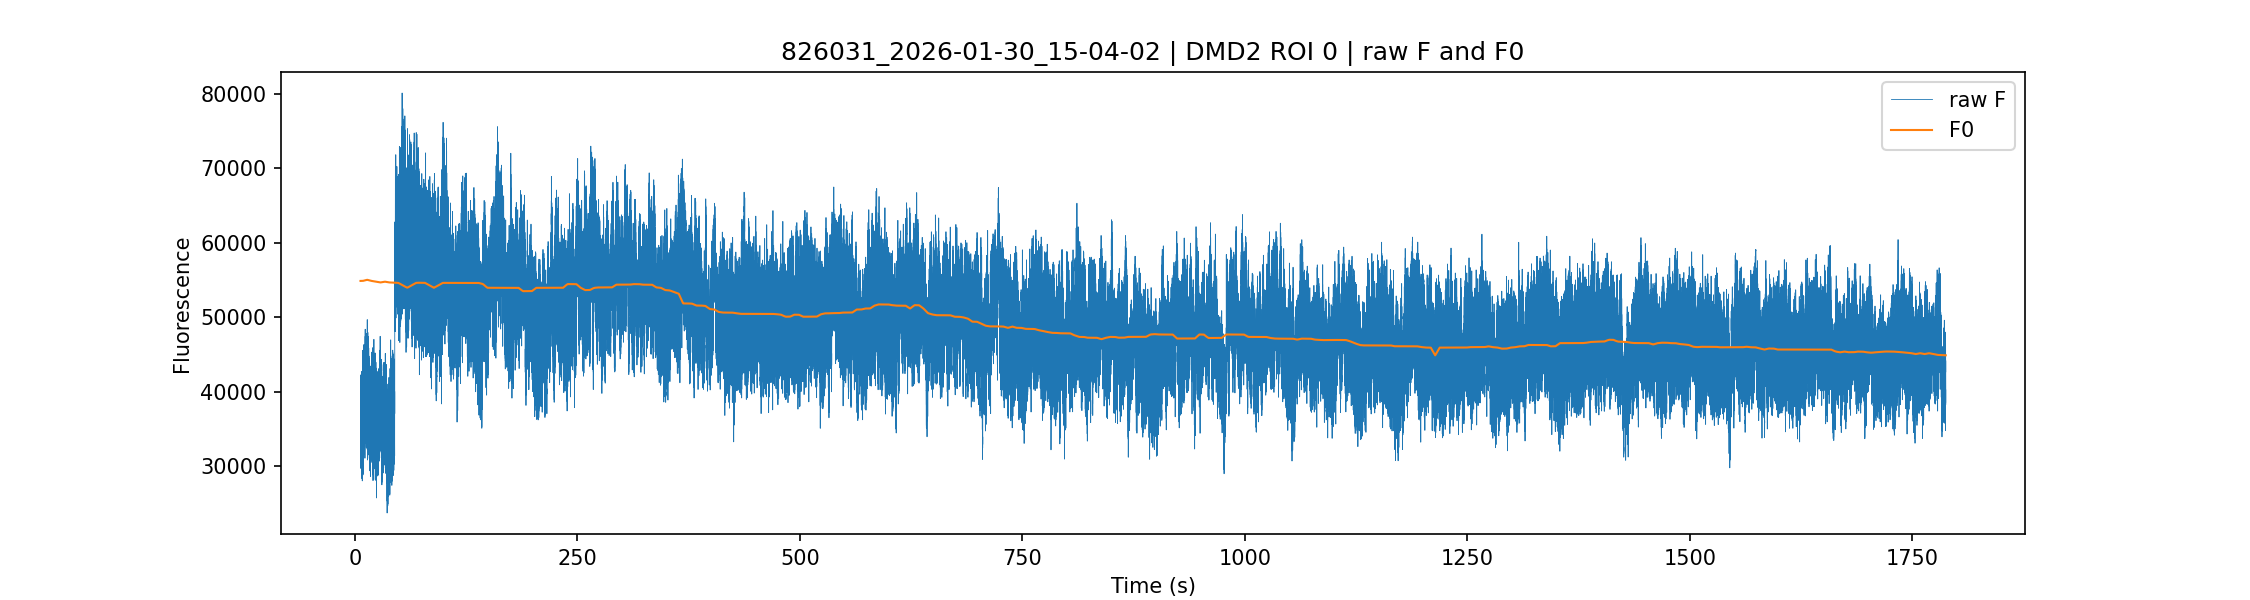

<IPython.core.display.Javascript object>


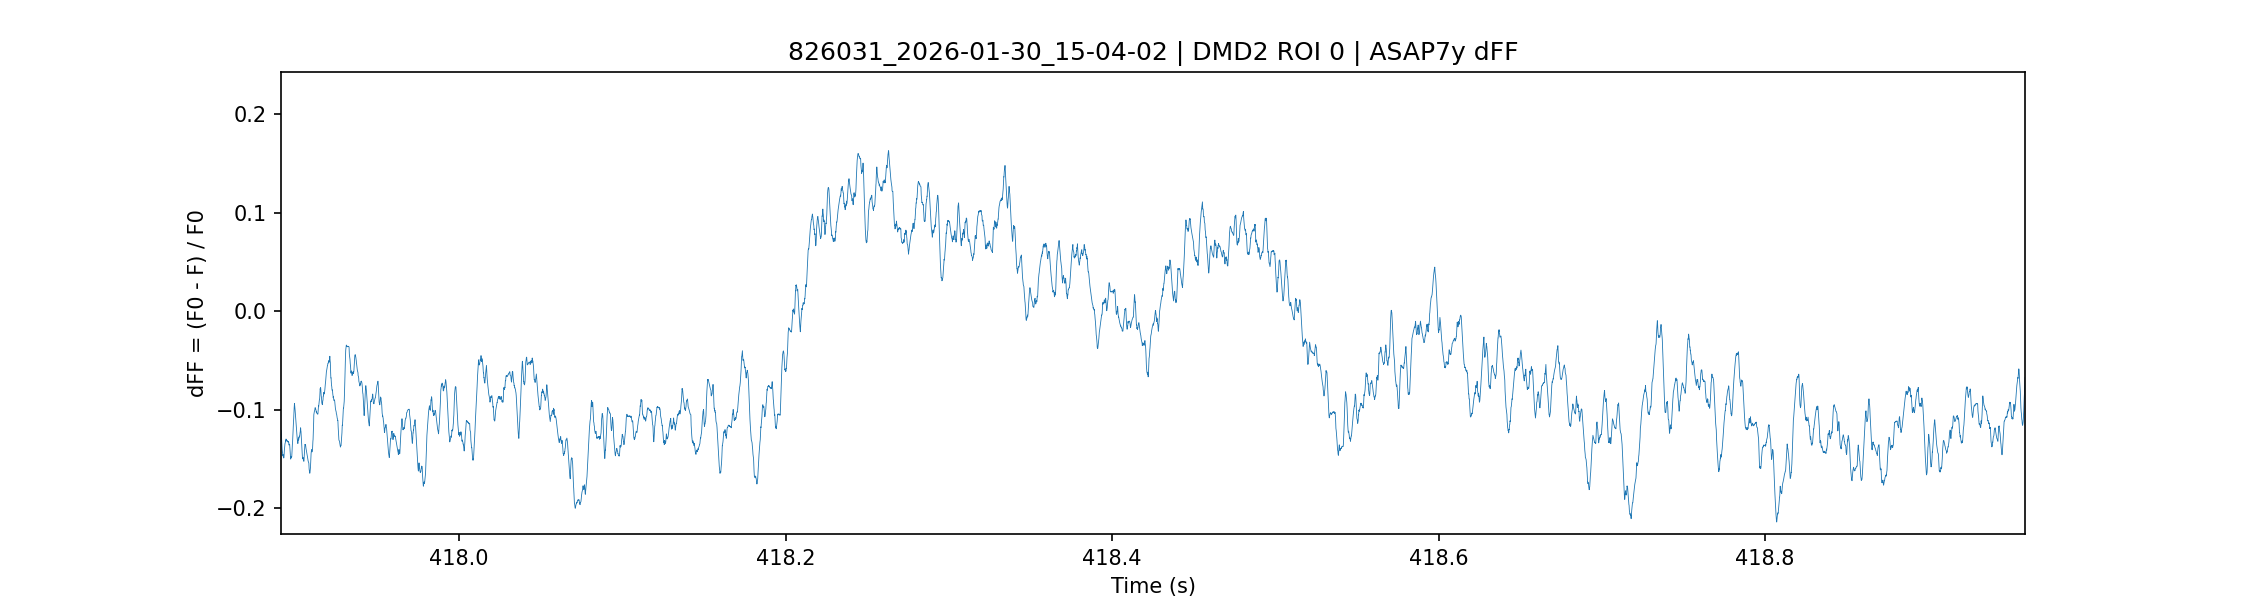

In [21]:
# Pick a voltage session and ROI to inspect.
# This cell uses the saved transform file produced by process_voltage_extraction.

voltage_assets = [a for a in assets if infer_modalities(a)["voltage"]]

if not voltage_assets:
    print("No voltage assets detected in the current session selection.")
else:
    asset = voltage_assets[0]
    dmd = 2
    roi_index = 0
    trace_signal = "dff_robust_f0"
    trace_mode = "trial"

    session_trace_h5 = asset.derived_subdir("voltage", create=False) / f"voltage_session_traces_{trace_signal}_{trace_mode}.h5"
    print("Inspecting:", session_trace_h5)

    if not session_trace_h5.exists():
        print("Session trace H5 not found. Run voltage extraction first, or use the next cell to compute one ROI on the fly.")
    else:
        roi = load_voltage_roi_transform_h5(session_trace_h5, dmd=dmd, roi_index=roi_index)
        t = roi["timebase_sec"]
        raw_f = roi["raw_f"]
        f0 = roi["f0"]
        dff = (raw_f-f0)/f0
#         dff = roi["dff"]

        fig, ax = plt.subplots(figsize=(15, 4))
        ax.plot(t, raw_f, lw=0.4, label="raw F")
        ax.plot(t, f0, lw=1.0, label="F0")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Fluorescence")
        ax.set_title(f"{asset.session_id} | DMD{dmd} ROI {roi_index} | raw F and F0")
        ax.legend()
        plt.show()

        fig, ax = plt.subplots(figsize=(15, 4))
        ax.plot(t, dff, lw=0.4)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("dFF = (F0 - F) / F0")
        ax.set_title(f"{asset.session_id} | DMD{dmd} ROI {roi_index} | ASAP7y dFF")
        plt.show()

## 9. Compute one voltage ROI transform on the fly

This is useful before committing to batch F0 settings. It reconstructs the full ROI trace from the session asset, estimates either static or robust F0, and returns `raw_f`, `f0`, and `dff` for visualization.


<IPython.core.display.Javascript object>


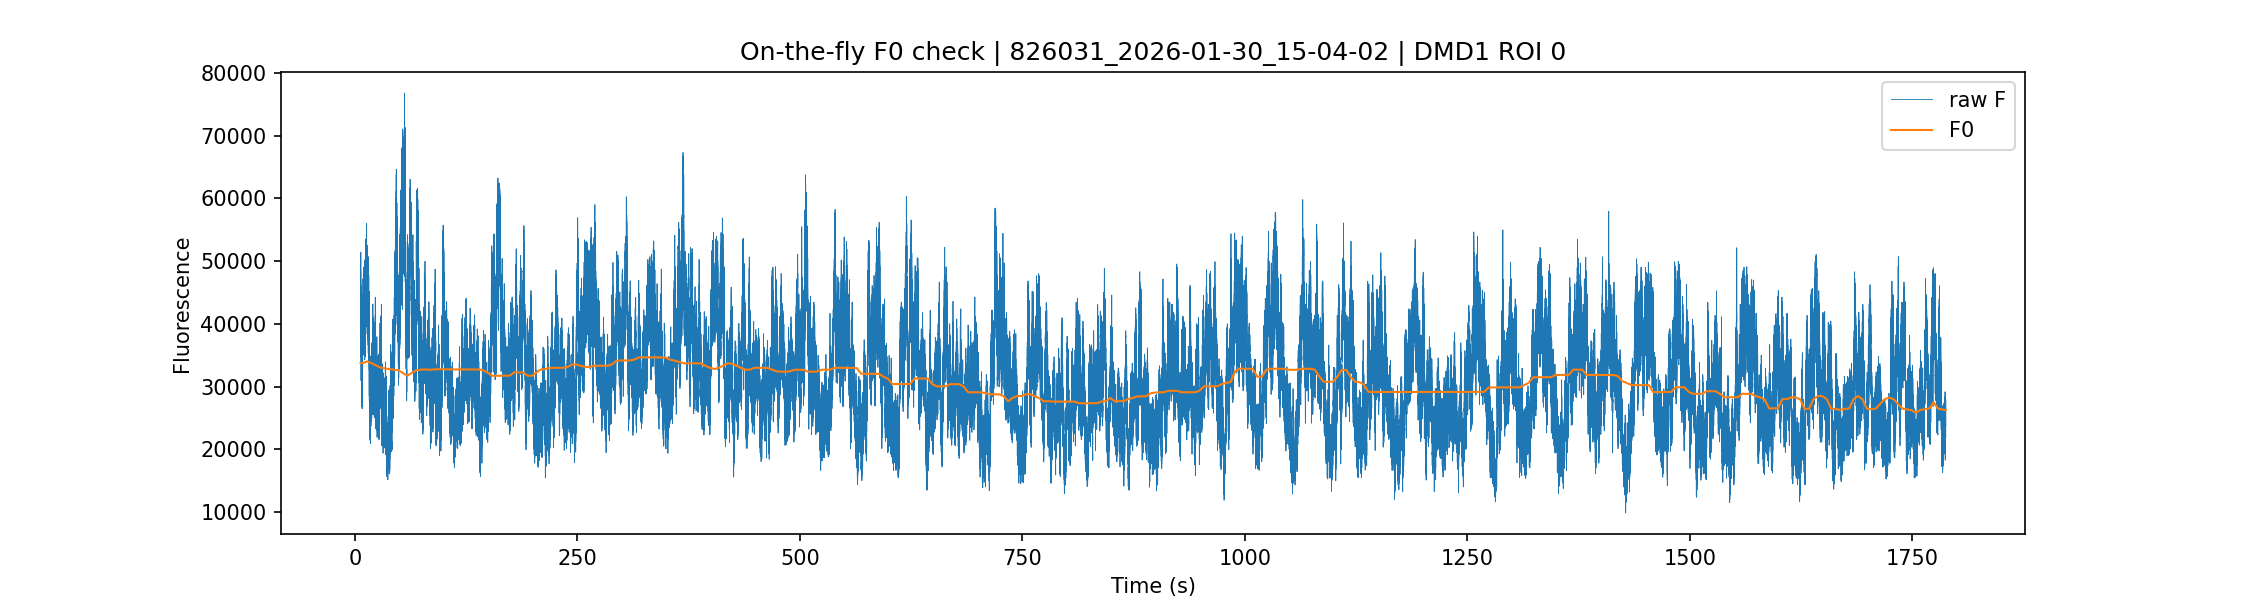

<IPython.core.display.Javascript object>


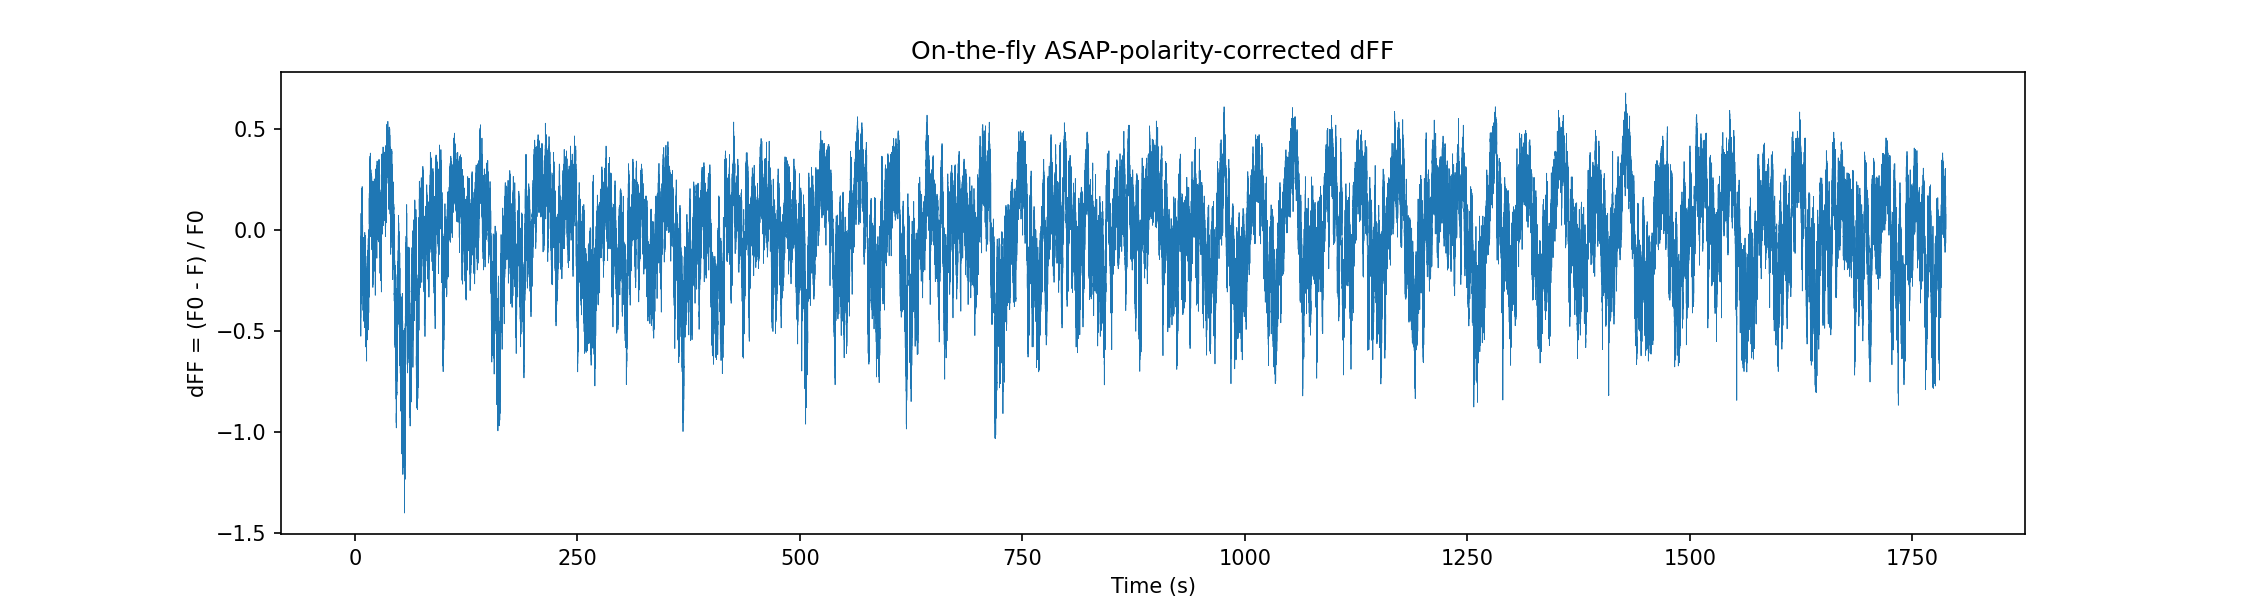

In [18]:
# Compute one ROI transform without running full event extraction.

if not voltage_assets:
    print("No voltage assets detected in the current session selection.")
else:
    asset = voltage_assets[0]
    dmd = 1
    roi_index = 0

    roi = compute_voltage_roi_transform_from_asset(
        asset,
        dmd=dmd,
        roi_index=roi_index,
        sample_rate_hz=VOLTAGE_SAMPLE_RATE_HZ,
        f0_method="robust",       # "static" or "robust"
        f0_percentile=50.0,
        robust_f0_bin_sec=5.0,
        robust_f0_smooth_sec=180.0,
    )

    t = roi["timebase_sec"]
    raw_f = roi["raw_f"]
    f0 = roi["f0"]
    dff = roi["dff"]

    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(t, raw_f, lw=0.4, label="raw F")
    ax.plot(t, f0, lw=1.0, label="F0")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fluorescence")
    ax.set_title(f"On-the-fly F0 check | {asset.session_id} | DMD{dmd} ROI {roi_index}")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(t, dff, lw=0.4)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("dFF = (F0 - F) / F0")
    ax.set_title("On-the-fly ASAP-polarity-corrected dFF")
    plt.show()

## 10. Expected output folders

For a fully processed session, outputs should look like:

```text
analysis/qc/behavior/
analysis/qc/slap2/              # glutamate synapse QC
analysis/qc/glutamate/
analysis/qc/calcium/
analysis/qc/voltage/
analysis/derived/glutamate/
analysis/derived/calcium/
analysis/derived/voltage/
```

For voltage, the key full-session transform output is:

```text
analysis/derived/voltage/voltage_session_traces_dff_static_f0_trial.h5
analysis/derived/voltage/voltage_session_traces_dff_robust_f0_trial.h5
```

Each contains `raw_f`, `f0`, and `dff`, enabling later reinspection of the F0 model and full-session ROI voltage dynamics.
